In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

import sys
from pathlib import Path

In [2]:
project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

from mc_engine import simulate
from mc_plots import plot_final_distributions, plot_negative_fraction_histograms, mc_analysis

In [3]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')

kelly_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
parlay_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_open.csv')

kelly_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
parlay_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close1.csv')

kelly_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
parlay_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close2.csv')

kelly_stacking_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking1.csv')
parlay_stacking_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_stacking1.csv')

kelly_stacking_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking.csv')
parlay_stacking_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_stacking.csv')



In [4]:
# test to make sure my win rate aligns with backtest

kelly_group = kelly_open.groupby('date').first().reset_index()
kelly_plus_ev = kelly_group[kelly_group['parlay_net'] != 0]
proportion_wins_kelly = (
    kelly_plus_ev.groupby('date')['parlay_net']
    .first()
    .gt(0)
    .mean()
)

proportion_wins_kelly

np.float64(0.589041095890411)

In [5]:
        
kelly_arr = [kelly_open, kelly_stacking_close1, kelly_stacking_close2]
kelly_arr = [df.reset_index(drop=True) for df in kelly_arr] 

parlay_arr = [parlay_open, parlay_stacking_close1, parlay_stacking_close2]
parlay_arr = [df.reset_index(drop=True) for df in parlay_arr] 

# open, stack1, stack2
probs = [.15, .5, .35]

mc_ml_open, mc_parlay_open, mc_total_open = simulate(
                                                    kelly_arr, 
                                                    parlay_arr, 
                                                    probs,
                                                    init_bankroll=500, 
                                                    n_sims=10000
                                                )

In [7]:
parlay_test = mc_parlay_open[-1]
print(len(parlay_test))
parlay_win = (parlay_test > 0).sum() / (len(parlay_test) )
print(parlay_win)

ml_test = mc_ml_open[0]
print(len(ml_test))
ml_win = (ml_test > 0).sum() / len(ml_test)
print(ml_win)

total_test = np.diff(mc_total_open[-1])
total_win = (total_test > 0).sum() / len(total_test) 
print(total_win)
print(len(total_test))

73
0.589041095890411
73
0.7123287671232876
0.6986301369863014
73


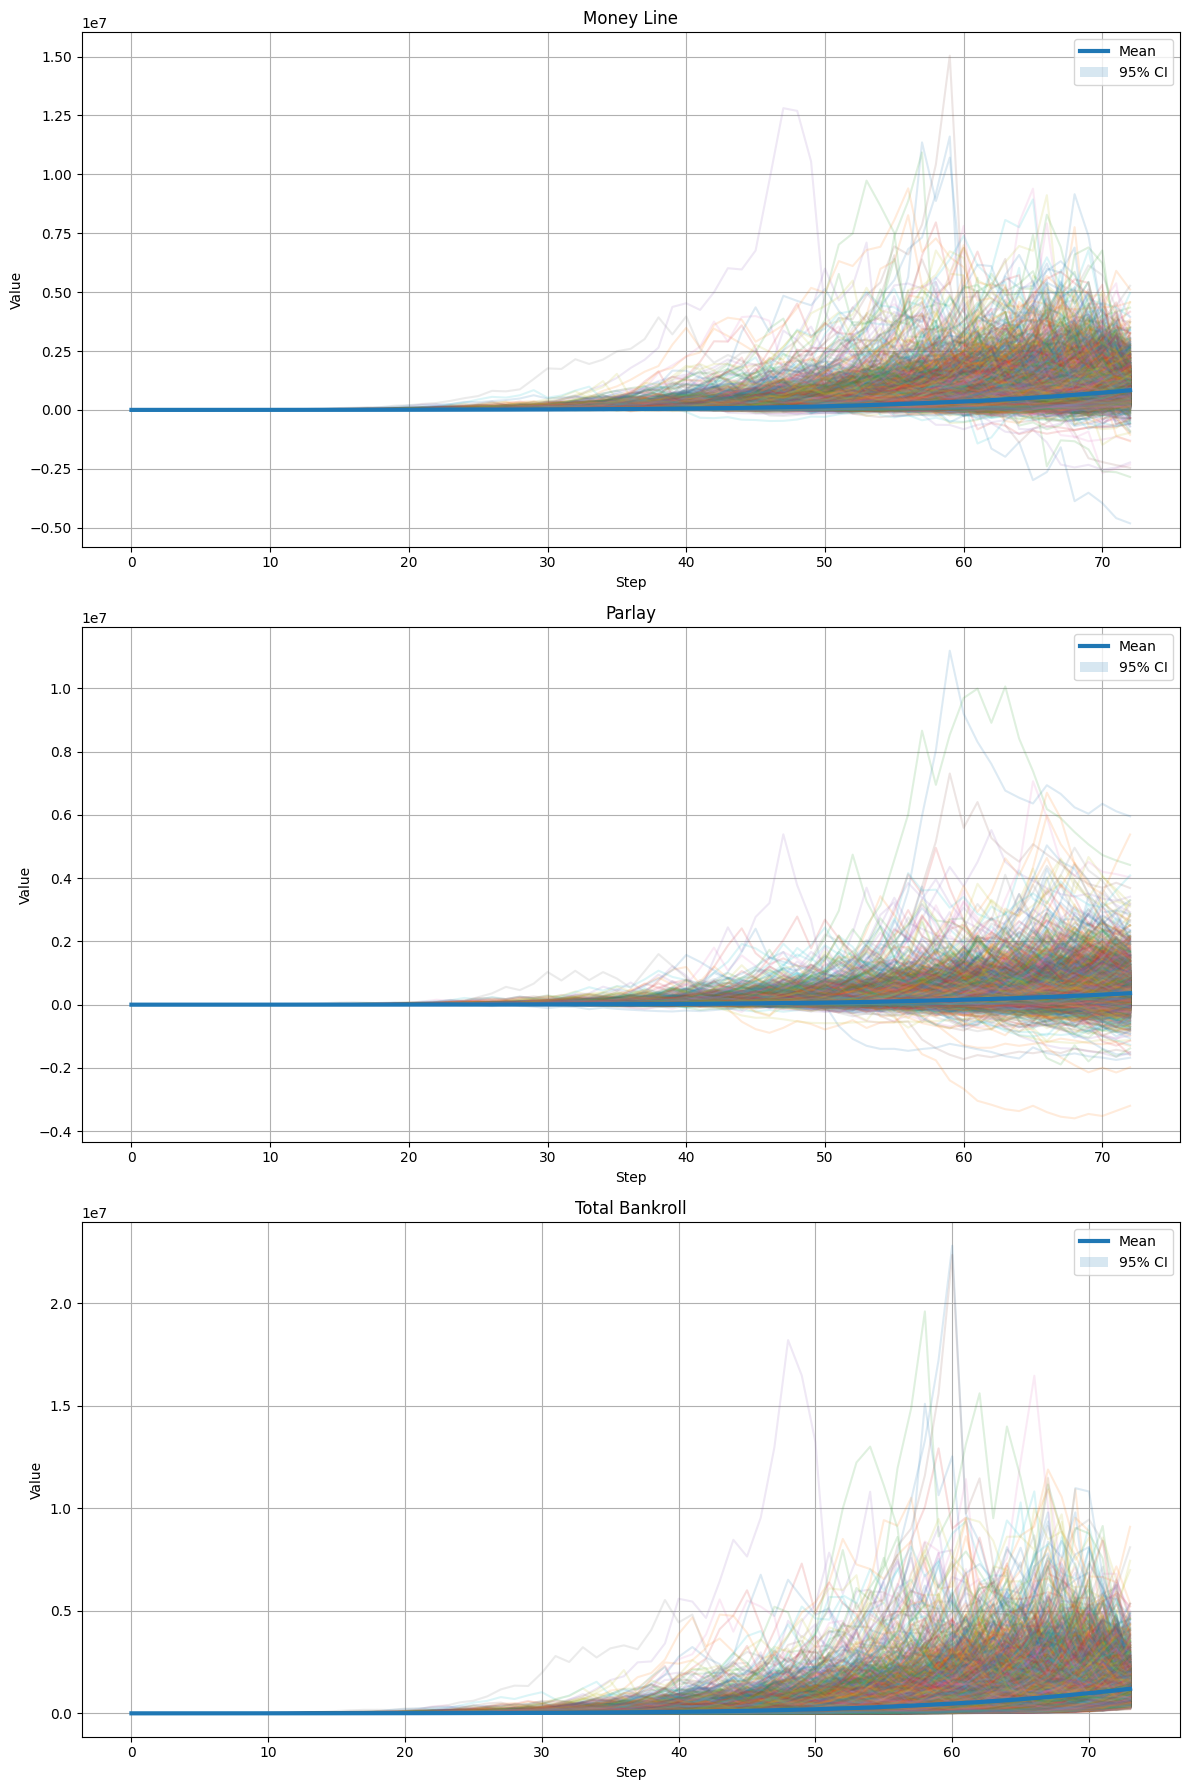

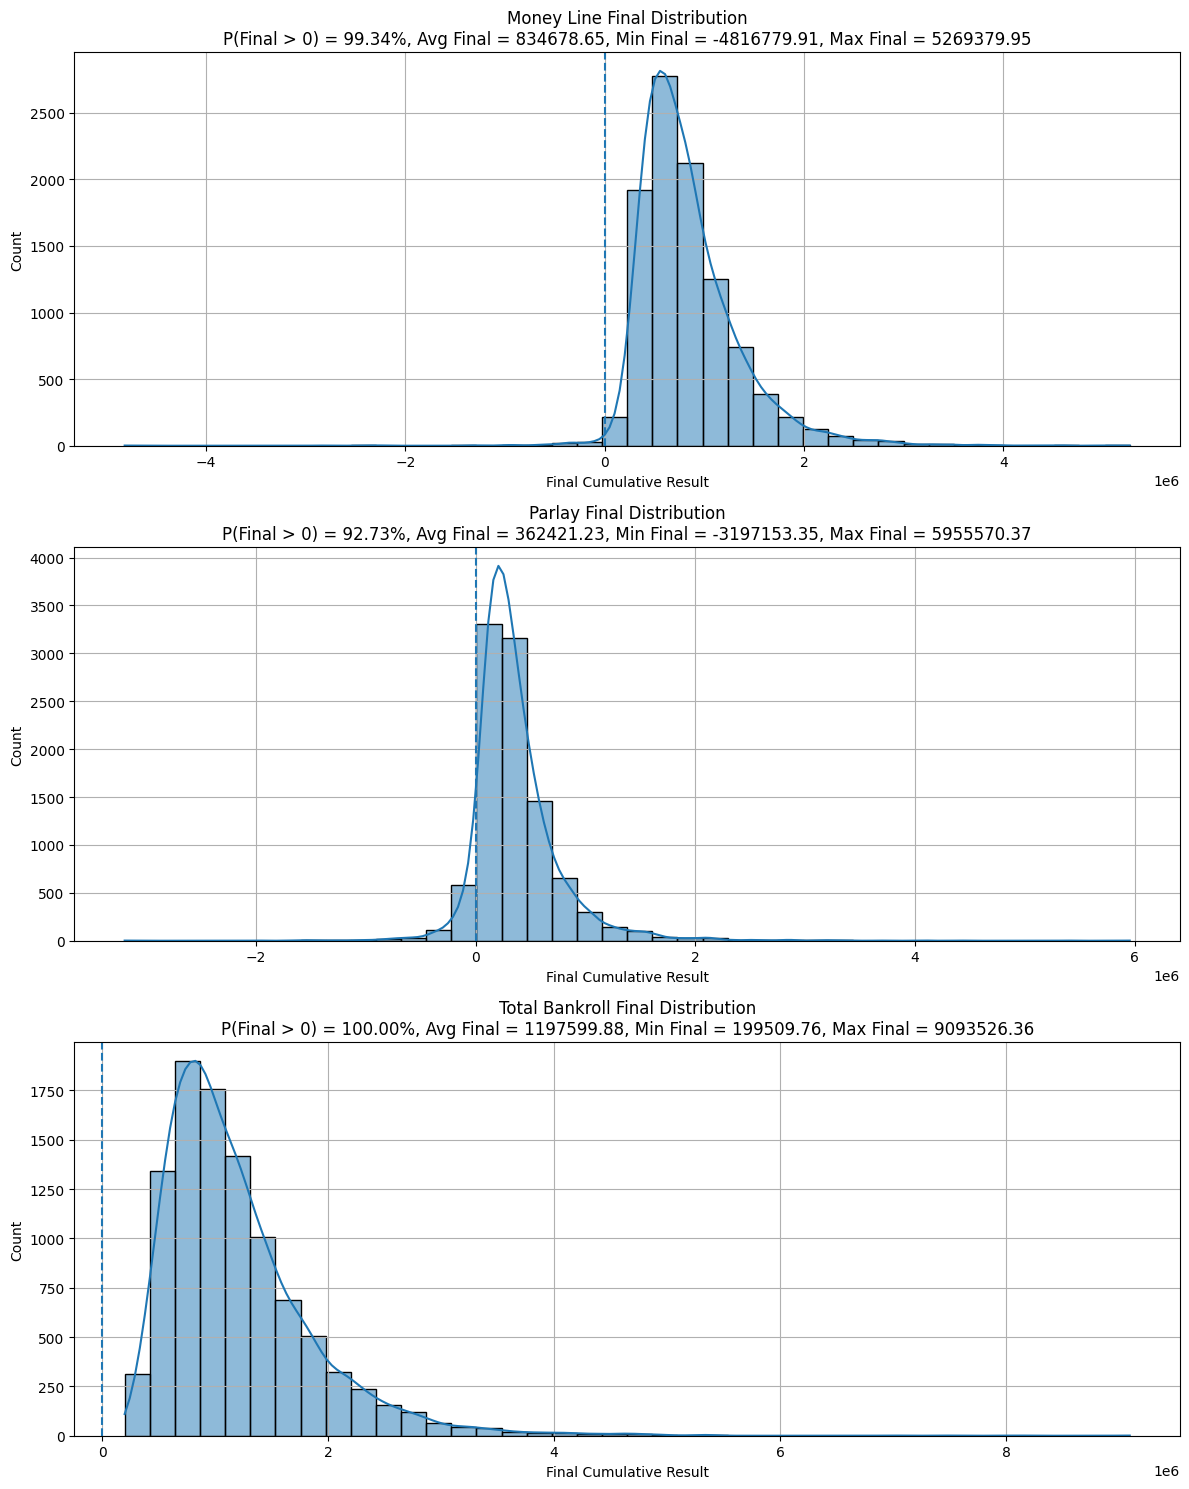

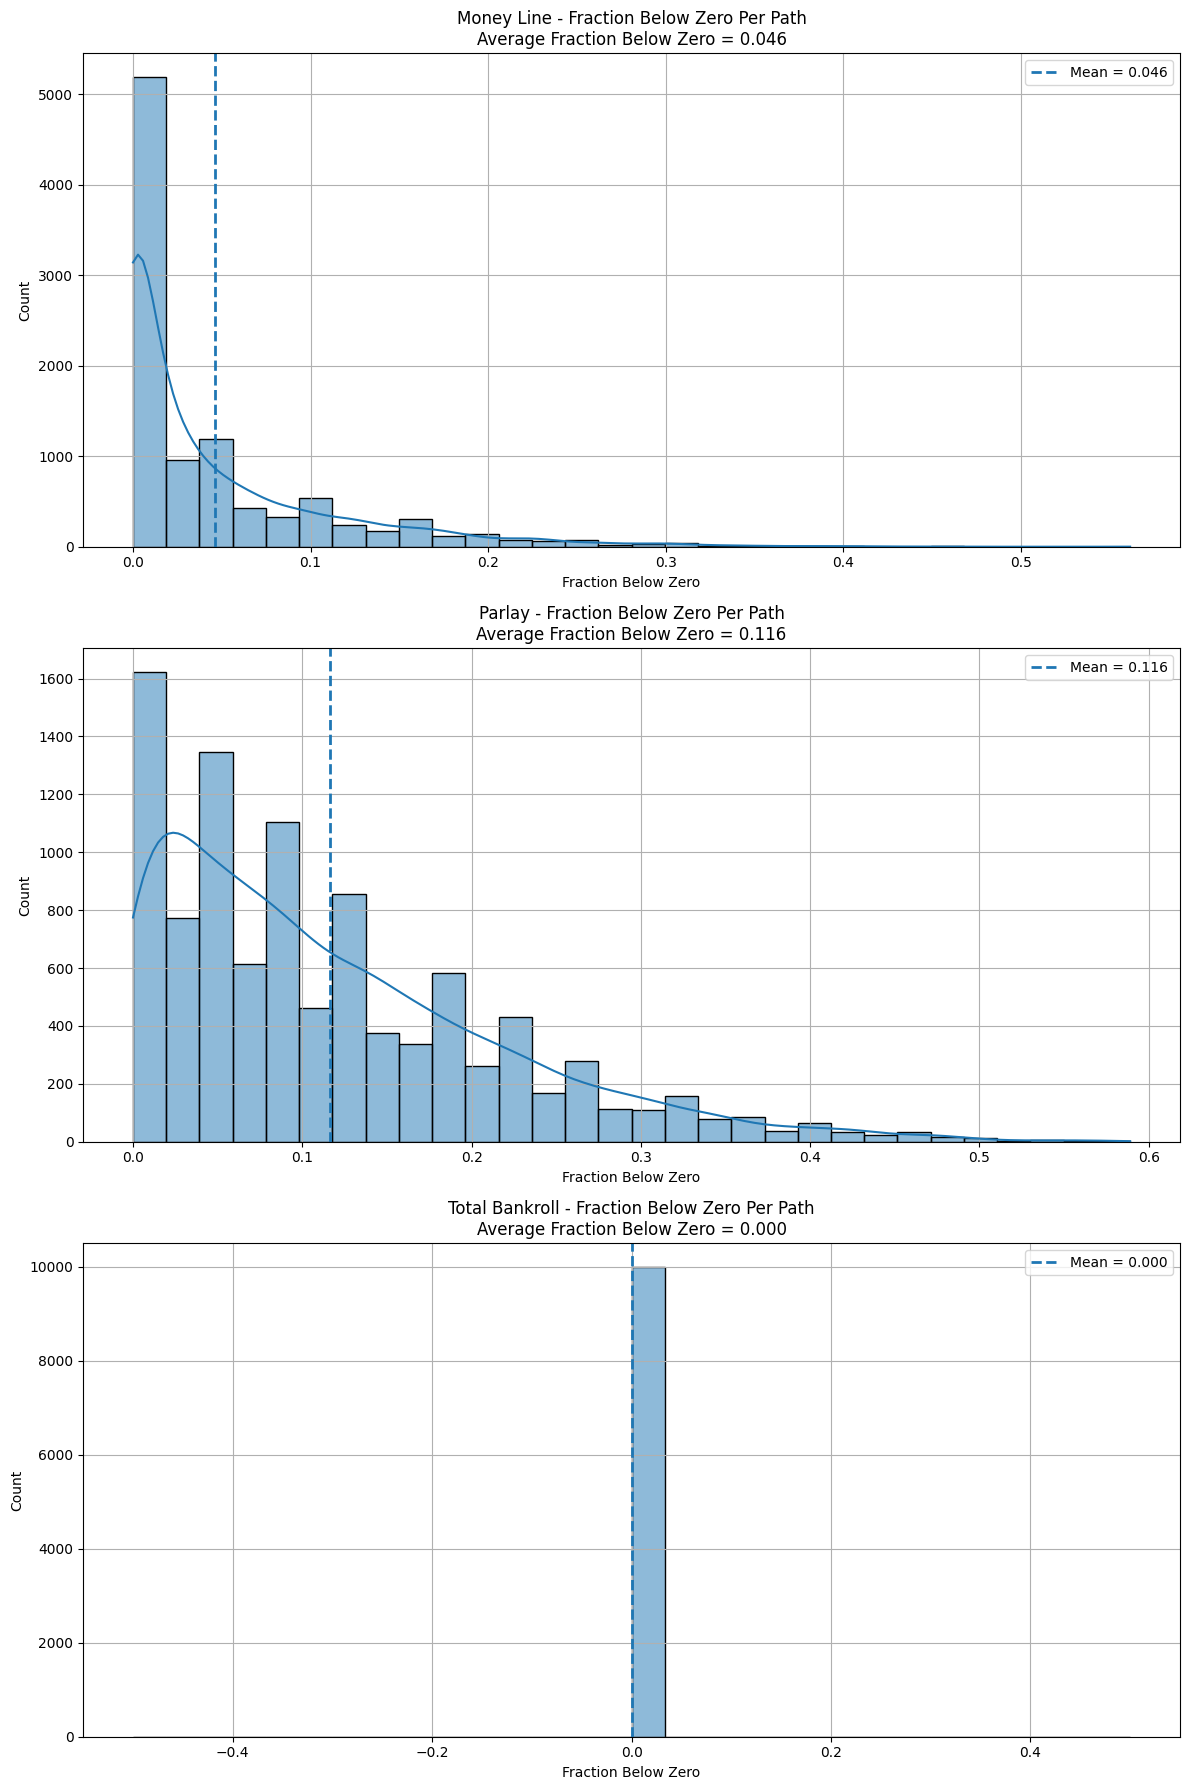

In [8]:
path1 = r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\mc_paths.png"
mc_analysis(mc_ml_open, mc_parlay_open, mc_total_open, path1)

path2 = r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\mc_hists.png"
plot_final_distributions(mc_ml_open, mc_parlay_open, mc_total_open, path2)

path3 = r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\mc_below_zero.png"
plot_negative_fraction_histograms(mc_ml_open, mc_parlay_open, mc_total_open, path3)
